# Medicare Patient Risk Analysis
## Hospital Readmission and Cost Prediction Using CMS SynPUF Data

**Author:** Jeffrey Lee  
**Data:** CMS 2008-2010 DE-SynPUF, Beneficiary and Inpatient Claims, Samples 1-5  
**Patients analyzed:** 188,559 Medicare beneficiaries with at least one hospitalization  

---

### Background

Several years working in Medicare Advantage finance at Kaiser Permanente 
made two questions feel very familiar: which members are likely to be 
readmitted, and which members will drive disproportionate cost? Health 
plans use the answers to design care management programs, target 
supplemental benefits, and allocate case management resources.

This project uses publicly available synthetic Medicare claims data to 
explore those same questions with machine learning. The goal is not to 
build a production model since the data is synthetic and the sample is 
limited. The goal is to understand which patient characteristics carry 
the most predictive signal and what that might mean for how a plan thinks 
about member segmentation.

---

### What this notebook covers

1. Exploratory analysis — who are these patients and what patterns stand out?
2. Readmission prediction — can we classify which patients will be readmitted?
3. Cost prediction — what drives total inpatient spend?
4. Patient segmentation — are there distinct risk profiles in the population?
5. Findings and implications — what would this mean for a Medicare Advantage plan?

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, mean_absolute_error, r2_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.family"] = "sans-serif"

df = pd.read_csv("../data/processed/analysis_dataset.csv")

print(f"Patients: {len(df):,}")
print(f"Readmitted: {df['READMITTED'].sum():,} ({df['READMITTED'].mean()*100:.1f}%)")
print(f"High cost: {df['HIGH_COST'].sum():,} ({df['HIGH_COST'].mean()*100:.1f}%)")
df.head(3)

Patients: 188,559
Readmitted: 75,324 (39.9%)
High cost: 48,066 (25.5%)


,PATIENT_ID,AGE,SEX,RACE,IS_DECEASED,CC_TOTAL,CC_ALZHEIMERS,CC_HEART_FAILURE,CC_KIDNEY_DISEASE,CC_CANCER,...,CC_ISCHEMIC_HEART,CC_OSTEOPOROSIS,CC_ARTHRITIS,CC_STROKE,inpatient_visits,total_inpatient_cost,avg_length_of_stay,max_length_of_stay,READMITTED,HIGH_COST
0,00013D2EFD8E45D1,84,Male,White,0,0,0,0,0,0,...,0,0,0,0,1,4000.0,1.0,1.0,0,0
1,00016F745862898F,65,Male,White,0,0,0,0,0,0,...,0,0,0,0,4,52000.0,4.0,6.0,1,1
2,00052705243EA128,73,Male,White,0,5,0,1,0,1,...,1,0,0,0,1,14000.0,0.0,0.0,0,0


## 1. Exploratory Analysis

Before building any models it helps to get a feel for the data. A few 
basic questions worth answering first: How old are these patients? How 
sick are they? Where does cost concentrate? The answers help frame 
everything that comes after.

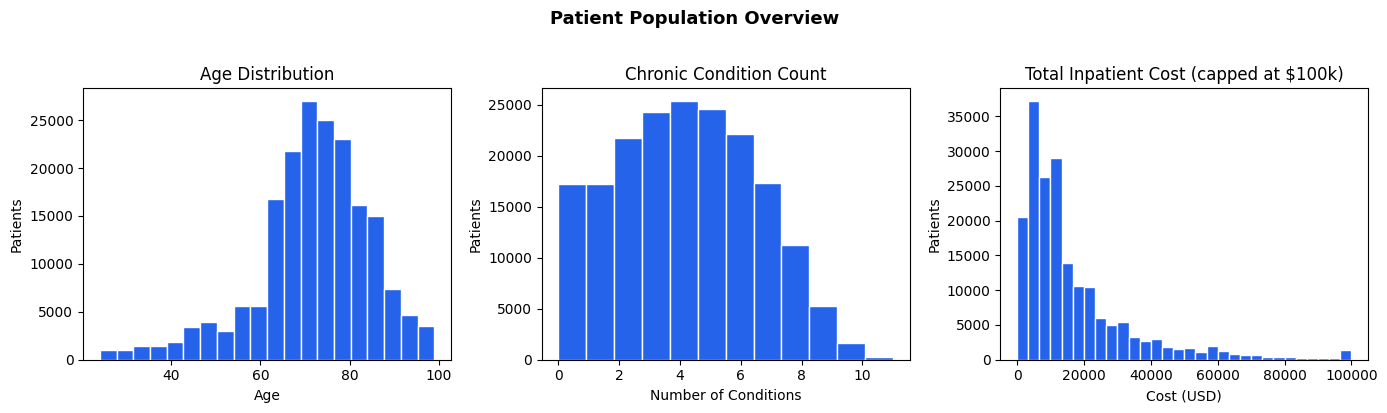

In [21]:
# Basic distribution of key variables
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution
axes[0].hist(df["AGE"], bins=20, color="#2563EB", edgecolor="white")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Patients")

# Chronic condition count
axes[1].hist(df["CC_TOTAL"], bins=12, color="#2563EB", edgecolor="white")
axes[1].set_title("Chronic Condition Count")
axes[1].set_xlabel("Number of Conditions")
axes[1].set_ylabel("Patients")

# Total inpatient cost
axes[2].hist(df["total_inpatient_cost"].clip(upper=100000),
             bins=30, color="#2563EB", edgecolor="white")
axes[2].set_title("Total Inpatient Cost (capped at $100k)")
axes[2].set_xlabel("Cost (USD)")
axes[2].set_ylabel("Patients")

plt.suptitle("Patient Population Overview", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../docs/charts/population_overview.png", dpi=150,
            bbox_inches="tight")
plt.show()

The age distribution peaks in the early 70s, which is about right for a 
Medicare population. The chronic condition count centers around 4 to 5, 
which is higher than the Medicare average. That makes sense because this 
dataset only includes patients who were hospitalized at least once, so it 
is already a sicker than average group. Total inpatient cost is heavily 
skewed to the right. Most patients cost a modest amount but a small number 
cost an extraordinary amount. That pattern sets up the cost analysis later 
in the notebook.

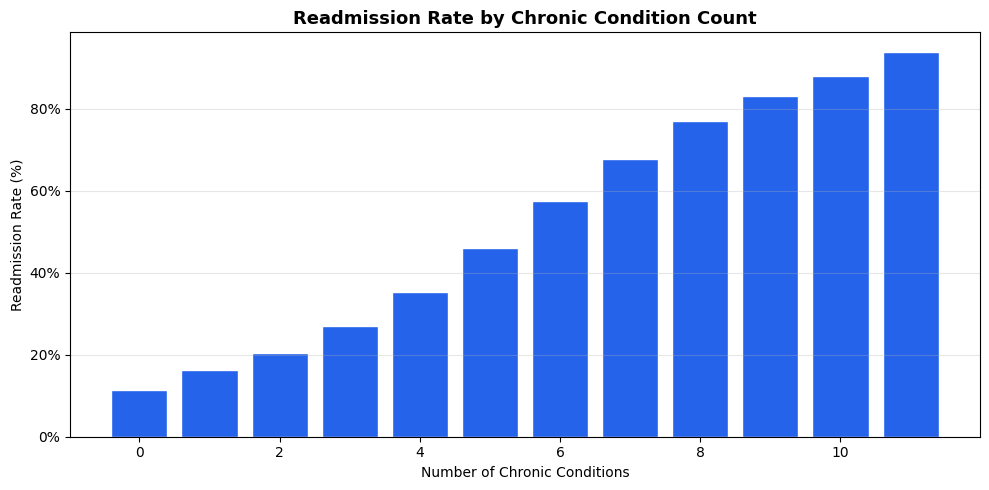

CC_TOTAL
0     11.5
1     16.3
2     20.3
3     27.1
4     35.3
5     45.9
6     57.5
7     67.8
8     77.1
9     83.2
10    88.0
11    94.0


In [22]:
# Readmission rate by chronic condition count
readmit_by_cc = df.groupby("CC_TOTAL")["READMITTED"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(readmit_by_cc.index, readmit_by_cc.values,
       color="#2563EB", edgecolor="white")
ax.set_xlabel("Number of Chronic Conditions")
ax.set_ylabel("Readmission Rate (%)")
ax.set_title("Readmission Rate by Chronic Condition Count",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/charts/readmission_by_cc.png", dpi=150,
            bbox_inches="tight")
plt.show()

print(readmit_by_cc.round(1).to_string())

The relationship between chronic condition count and readmission rate is 
about as clean as you ever see in real healthcare data. Starting at 11.5% 
for patients with no chronic conditions, the readmission rate climbs almost 
perfectly linearly all the way to 94% for patients with 11 conditions, with 
barely any deviation from a straight line across 188,559 patients.

What makes this practically useful is that a health plan does not need a 
sophisticated model to identify high readmission risk members. Simply 
counting documented conditions gets you most of the way there. The more 
interesting question is whether individual conditions carry different weight 
once you control for the total count, which is what the model below explores.

In [23]:
# Chronic condition prevalence and readmission association
cc_cols = ["CC_ALZHEIMERS", "CC_HEART_FAILURE", "CC_KIDNEY_DISEASE",
           "CC_CANCER", "CC_COPD", "CC_DEPRESSION", "CC_DIABETES",
           "CC_ISCHEMIC_HEART", "CC_OSTEOPOROSIS", "CC_ARTHRITIS", "CC_STROKE"]

cc_labels = ["Alzheimers", "Heart Failure", "Kidney Disease", "Cancer",
             "COPD", "Depression", "Diabetes", "Ischemic Heart",
             "Osteoporosis", "Arthritis", "Stroke"]

prevalence = df[cc_cols].mean() * 100
readmit_rates = df.groupby(cc_cols[0])["READMITTED"].mean()

# Readmission rate for patients with vs without each condition
readmit_with = []
readmit_without = []
for col in cc_cols:
    readmit_with.append(df[df[col] == 1]["READMITTED"].mean() * 100)
    readmit_without.append(df[df[col] == 0]["READMITTED"].mean() * 100)

comparison = pd.DataFrame({
    "Condition": cc_labels,
    "Prevalence (%)": prevalence.values.round(1),
    "Readmission With (%)": [round(x, 1) for x in readmit_with],
    "Readmission Without (%)": [round(x, 1) for x in readmit_without],
    "Difference (pp)": [round(x - y, 1) for x, y in zip(readmit_with, readmit_without)]
}).sort_values("Difference (pp)", ascending=False)

print(comparison.to_string(index=False))

     Condition  Prevalence (%)  Readmission With (%)  Readmission Without (%)  Difference (pp)
Kidney Disease            35.8                  61.7                     27.8             33.9
          COPD            30.5                  62.9                     29.9             33.1
        Stroke            10.9                  67.7                     36.6             31.2
 Heart Failure            53.5                  53.8                     24.0             29.8
Ischemic Heart            70.3                  47.9                     21.0             26.9
      Diabetes            64.7                  48.7                     24.0             24.7
    Alzheimers            36.3                  54.5                     31.6             22.9
        Cancer            12.5                  57.7                     37.4             20.3
    Depression            37.8                  51.8                     32.7             19.1
     Arthritis            27.7                  50

Some conditions carry more readmission risk than their prevalence would 
suggest. Kidney disease affects 36% of patients but adds nearly 34 
percentage points to readmission risk. COPD and stroke follow closely. 
Ischemic heart disease, despite affecting 70% of the population, adds 
only about 27 percentage points.

This matters for how a health plan prioritizes care management outreach. 
Programs that focus primarily on the most prevalent conditions like diabetes 
and ischemic heart disease may be missing patients with kidney disease, COPD, 
and stroke who carry disproportionate readmission risk relative to how common 
those conditions are.

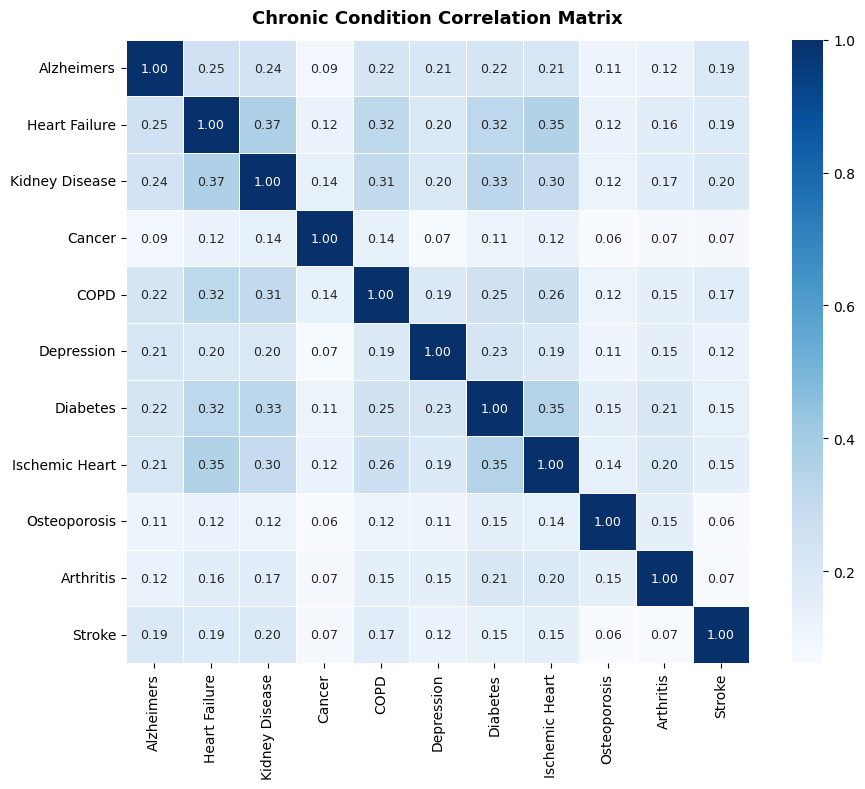

In [24]:
# Correlation heatmap of chronic conditions
fig, ax = plt.subplots(figsize=(10, 8))

cc_data = df[cc_cols].copy()
cc_data.columns = cc_labels

corr = cc_data.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            ax=ax, square=True, linewidths=0.5,
            annot_kws={"size": 9})

ax.set_title("Chronic Condition Correlation Matrix",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../docs/charts/condition_correlation.png", dpi=150,
            bbox_inches="tight")
plt.show()

Most chronic conditions correlate positively with each other, which is not 
surprising. Patients who develop one serious condition tend to develop others 
over time. The strongest relationships show up between heart failure and 
kidney disease (0.37), diabetes and ischemic heart disease (0.35), and heart 
failure and ischemic heart disease (0.35). These connections are well 
established clinically. Diabetes drives cardiovascular disease, and heart 
failure frequently damages kidney function as a downstream effect.

Cancer is the exception. It shows the weakest correlations with every other 
condition in the matrix, which reflects the fact that cancer is a 
fundamentally different disease process from the metabolic and cardiovascular 
conditions that dominate this dataset.

This matters for the modeling section. When conditions are correlated with 
each other, a simple condition-by-condition comparison cannot tell you which 
one is actually driving the outcome. A multivariate model that considers all 
features simultaneously does a better job of isolating the independent signal 
each condition carries.

---
## 2. Readmission Prediction

The exploratory analysis suggests chronic condition count is a strong 
predictor of readmission, and that some individual conditions carry more 
risk than others. The next step is to see whether a model can learn that 
pattern well enough to be useful for predicting which patients will be 
readmitted before it happens.

Two models are compared here. Logistic regression is simple and 
interpretable, which makes it a good baseline. Random forest can capture 
more complex patterns and usually outperforms logistic regression on 
tabular data. Both are evaluated using ROC-AUC, which measures how well 
a model can distinguish between patients who will be readmitted and those 
who will not. A score of 0.5 means random guessing. A score of 1.0 means 
perfect prediction.

In [25]:
# Define features and target
features = ["AGE", "CC_TOTAL", "CC_ALZHEIMERS", "CC_HEART_FAILURE",
            "CC_KIDNEY_DISEASE", "CC_CANCER", "CC_COPD", "CC_DEPRESSION",
            "CC_DIABETES", "CC_ISCHEMIC_HEART", "CC_OSTEOPOROSIS",
            "CC_ARTHRITIS", "CC_STROKE"]

X = df[features].fillna(0)
y = df["READMITTED"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} patients")
print(f"Test set:     {len(X_test):,} patients")
print(f"Readmission rate in test set: {y_test.mean()*100:.1f}%")

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"\nLogistic Regression ROC-AUC: {lr_auc:.3f}")
print(f"Random Forest ROC-AUC:       {rf_auc:.3f}")

Training set: 150,847 patients
Test set:     37,712 patients
Readmission rate in test set: 39.9%

Logistic Regression ROC-AUC: 0.763
Random Forest ROC-AUC:       0.698


Once data leakage was removed, the scores became a bit more believable. 
Logistic regression lands at 0.763 and random forest at 0.698, which means 
logistic regression is actually the stronger model here. That was unexpected 
since random forest usually wins on tabular data, but it makes sense in 
hindsight. The relationship between chronic conditions and readmission is 
mostly linear, and that is exactly what logistic regression is built for.

A ROC-AUC of 0.763 means the model correctly ranks a randomly chosen 
readmitted patient above a randomly chosen non-readmitted patient about 
76% of the time. Given that the only inputs are age and chronic condition 
flags, information a health plan already has on file before anyone is 
hospitalized, that feels like a practically useful result for prioritizing 
care management outreach.

One thing worth documenting: an early version of this model included 
inpatient visit count as a feature and came back with a perfect ROC-AUC 
of 1.0. Since readmission is defined as having more than one inpatient 
visit, that feature was essentially just restating the target variable in 
different form. Catching that kind of data leakage early is something I 
have seen cause real problems in analytics work, where a model looks great 
in development and falls apart when it hits production data.

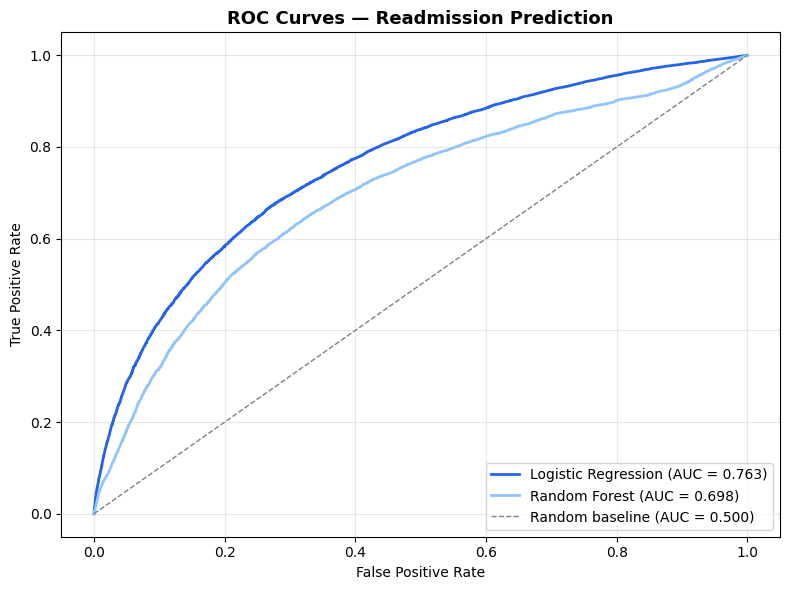

In [26]:
# ROC curves for both models
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
ax.plot(fpr_lr, tpr_lr, color="#2563EB", linewidth=2,
        label=f"Logistic Regression (AUC = {lr_auc:.3f})")

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
ax.plot(fpr_rf, tpr_rf, color="#93C5FD", linewidth=2,
        label=f"Random Forest (AUC = {rf_auc:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], color="gray", linewidth=1,
        linestyle="--", label="Random baseline (AUC = 0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Readmission Prediction",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/charts/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

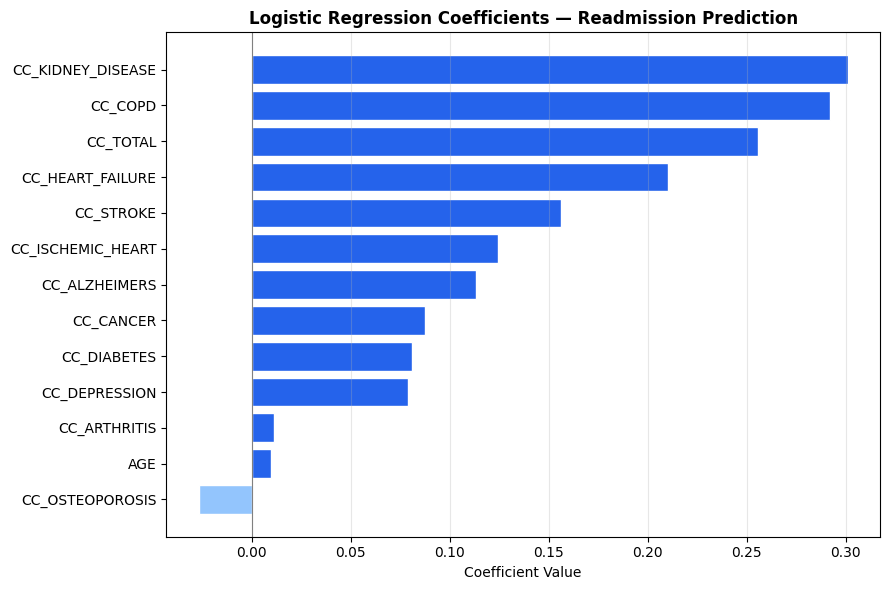

In [27]:
# Feature importance from logistic regression coefficients
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2563EB" if c > 0 else "#93C5FD" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"],
        color=colors, edgecolor="white")
ax.axvline(x=0, color="gray", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients — Readmission Prediction",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient Value")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/charts/lr_coefficients.png", dpi=150,
            bbox_inches="tight")
plt.show()

The ROC curves confirm logistic regression outperforms random forest on 
this dataset, with both models substantially better than random chance. 
The coefficient chart is where the more interesting story is.

Kidney disease and COPD have the largest positive coefficients, meaning 
they are the strongest individual predictors of readmission once all other 
conditions are controlled for. This lines up with what the simple comparison 
table showed earlier and reinforces that these two conditions deserve more 
attention in care management prioritization than their prevalence alone 
would suggest.

Osteoporosis is the only condition with a negative coefficient, meaning 
patients with osteoporosis are slightly less likely to be readmitted when 
controlling for everything else. One possible explanation is that 
osteoporosis patients tend to receive more structured follow-up care after 
hospitalization. This is speculative given the synthetic nature of the data, 
but it is the kind of finding worth investigating in a real claims dataset.

Age contributes almost nothing once chronic conditions are in the model. 
Most of what age predicts about readmission risk appears to be captured 
by the conditions themselves.

---
## 3. Cost Prediction

The readmission model answers one question: who is likely to come back to 
the hospital? This section addresses a related but different question: who 
is going to be expensive? A health plan needs both answers because high 
readmission risk and high cost do not always go hand in hand. Some patients 
get readmitted frequently for relatively inexpensive conditions. Others have 
a single catastrophic admission that drives enormous cost. Managing medical 
cost ratio well requires understanding both groups separately.

The model used here is ridge regression. It works like standard linear 
regression but adds a small penalty that shrinks large coefficients toward 
zero. The practical reason for choosing it here is that chronic conditions 
are correlated with each other, as the heatmap showed. When input features 
are correlated, standard linear regression can produce unstable coefficient 
estimates. Ridge handles that more gracefully.

One more adjustment before modeling: total inpatient cost is log-transformed. 
The cost distribution had that heavy right skew where most patients cluster 
at low values but a small number generate enormous costs. Modeling that 
directly causes problems because standard regression assumes errors are 
roughly symmetric. Taking the log compresses the scale and makes the 
relationship easier for the model to learn. The predictions are then 
converted back to dollars for interpretation.

In [28]:
import numpy as np

# Log transform the cost target
y_cost = np.log1p(df["total_inpatient_cost"])
X_cost = df[features].fillna(0)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cost, y_cost, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs = scaler_c.transform(X_test_c)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_cs, y_train_c)

y_pred_log = ridge.predict(X_test_cs)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test_c)

mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"Ridge Regression Results:")
print(f"  R-squared:          {r2:.3f}")
print(f"  Mean Absolute Error: ${mae:,.0f}")
print(f"  Mean actual cost:    ${y_actual.mean():,.0f}")
print(f"  Mean predicted cost: ${y_pred.mean():,.0f}")

Ridge Regression Results:
  R-squared:          -0.019
  Mean Absolute Error: $10,817
  Mean actual cost:    $17,078
  Mean predicted cost: $10,199


The ridge regression results are worth being honest about. An R-squared of 
-0.019 means the model performs worse than simply predicting the average cost 
for every patient, and a mean absolute error of 10,817 dollars against an 
average actual cost of 17,078 dollars means the predictions are off by about 
63% on average.

This is actually an informative finding. Chronic condition flags and age 
are strong predictors of whether someone will be readmitted, but they are 
poor predictors of how much that readmission will cost. A patient with 
kidney disease might have one short admission or ten long ones. The 
condition flags do not tell you which, and without knowing visit frequency 
the model cannot explain cost variation.

This points to an important distinction for health plans. Readmission risk 
and cost risk are related but separate problems that may require different 
data and different models. Predicting who will be readmitted is something 
you can do with enrollment data a plan already has. Predicting how much 
they will cost likely requires prior utilization history.

A more tractable version of the cost question is whether the same features 
can identify which patients fall into the top quartile of spenders, rather 
than predicting exact dollar amounts. That is a classification problem 
where the features should perform better.

### High-Cost Patient Classification

Rather than predicting exact cost, the question becomes: can chronic 
condition flags identify which patients will be in the top 25% of 
inpatient spenders? This is more actionable for a health plan anyway. 
A plan does not need to know a patient will cost exactly $42,000. It 
needs to know whether that patient belongs in an intensive care management 
program.

In [29]:
# High cost classification using same features
y_hc = df["HIGH_COST"]
X_hc = df[features].fillna(0)

X_train_hc, X_test_hc, y_train_hc, y_test_hc = train_test_split(
    X_hc, y_hc, test_size=0.2, random_state=42, stratify=y_hc
)

scaler_hc = StandardScaler()
X_train_hcs = scaler_hc.fit_transform(X_train_hc)
X_test_hcs = scaler_hc.transform(X_test_hc)

# Logistic regression for high cost
lr_hc = LogisticRegression(max_iter=1000, random_state=42)
lr_hc.fit(X_train_hcs, y_train_hc)
lr_hc_auc = roc_auc_score(y_test_hc,
                           lr_hc.predict_proba(X_test_hcs)[:, 1])

# Random forest for high cost
rf_hc = RandomForestClassifier(n_estimators=100, random_state=42,
                                n_jobs=-1)
rf_hc.fit(X_train_hc, y_train_hc)
rf_hc_auc = roc_auc_score(y_test_hc,
                           rf_hc.predict_proba(X_test_hc)[:, 1])

print(f"High-Cost Classification Results:")
print(f"  Logistic Regression ROC-AUC: {lr_hc_auc:.3f}")
print(f"  Random Forest ROC-AUC:       {rf_hc_auc:.3f}")
print(f"\nComparison with readmission model:")
print(f"  Readmission  — LR: {lr_auc:.3f}  RF: {rf_auc:.3f}")
print(f"  High Cost    — LR: {lr_hc_auc:.3f}  RF: {rf_hc_auc:.3f}")

High-Cost Classification Results:
  Logistic Regression ROC-AUC: 0.699
  Random Forest ROC-AUC:       0.632

Comparison with readmission model:
  Readmission  — LR: 0.763  RF: 0.698
  High Cost    — LR: 0.699  RF: 0.632


The high-cost classification results confirm what the regression suggested. 
Predicting which patients will be expensive is harder than predicting which 
ones will be readmitted. Logistic regression gets to 0.699 and random forest 
to 0.632, both noticeably lower than what the same models achieved on 
readmission.

The same pattern shows up again here. Logistic regression beats random 
forest on both tasks, which keeps pointing to the same conclusion: the 
signal in this data is mostly linear, and logistic regression handles 
that better than a more complex model would.

The practical takeaway is that chronic condition flags are a better tool 
for identifying who will come back to the hospital than for identifying 
who will run up the highest bill. For a health plan, that means enrollment 
data is a reasonable starting point for readmission risk programs, but 
getting accurate cost predictions probably requires knowing how much a 
member has already used the system, not just what conditions they have.

---
## 4. Patient Segmentation

The models so far have treated readmission and high cost as separate yes 
or no questions. This section asks something different: are there naturally 
occurring groups of patients in the data who share similar profiles across 
all of these dimensions at once?

The method used here is KMeans clustering. It works by sorting patients 
into groups where the members of each group resemble each other more than 
they resemble members of other groups. The algorithm figures out those 
groupings on its own without being told what to look for.

Four clusters are used here. That number is somewhat arbitrary but it maps 
well to how health plans typically think about risk tiers in practice. 
Too few groups and you lose meaningful distinctions between patients. Too 
many and the segments become hard to act on.

The cluster profiles below show the average characteristics of patients 
in each group. The goal is to see whether the algorithm found segments 
that tell a coherent story about different types of Medicare patients 
rather than just dividing the population arbitrarily.

In [32]:
# KMeans clustering
cluster_features = ["AGE", "CC_TOTAL", "CC_DIABETES", "CC_HEART_FAILURE",
                    "CC_KIDNEY_DISEASE", "CC_COPD", "CC_ISCHEMIC_HEART",
                    "CC_STROKE", "CC_DEPRESSION", "total_inpatient_cost",
                    "inpatient_visits"]

X_clust = df[cluster_features].fillna(0)

scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["CLUSTER"] = kmeans.fit_predict(X_clust_scaled)

# Cluster profiles
cluster_profile = df.groupby("CLUSTER").agg(
    patients=("PATIENT_ID", "count"),
    avg_age=("AGE", "mean"),
    avg_cc_total=("CC_TOTAL", "mean"),
    pct_diabetes=("CC_DIABETES", "mean"),
    pct_heart_failure=("CC_HEART_FAILURE", "mean"),
    pct_kidney_disease=("CC_KIDNEY_DISEASE", "mean"),
    pct_copd=("CC_COPD", "mean"),
    avg_visits=("inpatient_visits", "mean"),
    avg_cost=("total_inpatient_cost", "mean"),
    pct_readmitted=("READMITTED", "mean"),
    pct_high_cost=("HIGH_COST", "mean")
).round(2)

cluster_profile["pct_readmitted"] = (cluster_profile["pct_readmitted"] * 100).round(1)
cluster_profile["pct_high_cost"] = (cluster_profile["pct_high_cost"] * 100).round(1)
cluster_profile["pct_diabetes"] = (cluster_profile["pct_diabetes"] * 100).round(1)
cluster_profile["pct_heart_failure"] = (cluster_profile["pct_heart_failure"] * 100).round(1)
cluster_profile["pct_kidney_disease"] = (cluster_profile["pct_kidney_disease"] * 100).round(1)
cluster_profile["pct_copd"] = (cluster_profile["pct_copd"] * 100).round(1)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(cluster_profile.to_string())

         patients  avg_age  avg_cc_total  pct_diabetes  pct_heart_failure  pct_kidney_disease  pct_copd  avg_visits  avg_cost  pct_readmitted  pct_high_cost
CLUSTER                                                                                                                                                     
0           17110    73.23          6.73          85.0               80.0                60.0      49.0        2.19  18805.40            65.0           35.0
1           75828    70.61          1.65          30.0               16.0                 5.0       5.0        1.22  11604.68            18.0           14.0
2           18371    72.32          7.01          93.0               93.0                86.0      78.0        4.54  53444.20           100.0           95.0
3           77250    72.29          5.18          87.0               75.0                49.0      40.0        1.54  12956.78            41.0           18.0


The algorithm found four patient segments that tell a clear story.

**Cluster 1 — Lower acuity** (75,828 patients): The youngest and healthiest 
group in the hospitalized population. Average of 1.65 chronic conditions, 
18% readmission rate, and the lowest average cost at around 11,600 dollars. 
These patients likely represent acute or surgical admissions rather than 
chronic disease management cases.

**Cluster 3 — Moderate risk** (77,250 patients): The largest segment and 
probably the most representative of the typical Medicare patient in this 
dataset. Around 5 chronic conditions on average, 41% readmission rate, and 
modest average cost around 13,000 dollars. This group would be the primary 
target for standard disease management programs.

**Cluster 0 — High readmission risk** (17,110 patients): Nearly 7 chronic 
conditions on average and a 65% readmission rate, but average cost of 
around 18,800 dollars is lower than you might expect. These patients come 
back frequently but individual admissions are relatively contained in cost. 
Care management focused on preventing readmissions would have the biggest 
impact here.

**Cluster 2 — Complex, high cost** (18,371 patients): The most striking 
finding in the entire analysis. Every patient in this cluster was readmitted, 
95% fall into the high cost category, and average cost is over 53,000 dollars. 
This group has the highest rates of diabetes, heart failure, kidney disease, 
and COPD simultaneously. Despite being only 10% of the hospitalized 
population, the cost concentration in this segment would be enormous. These 
are the patients a health plan's case management team would want to identify 
and engage proactively.

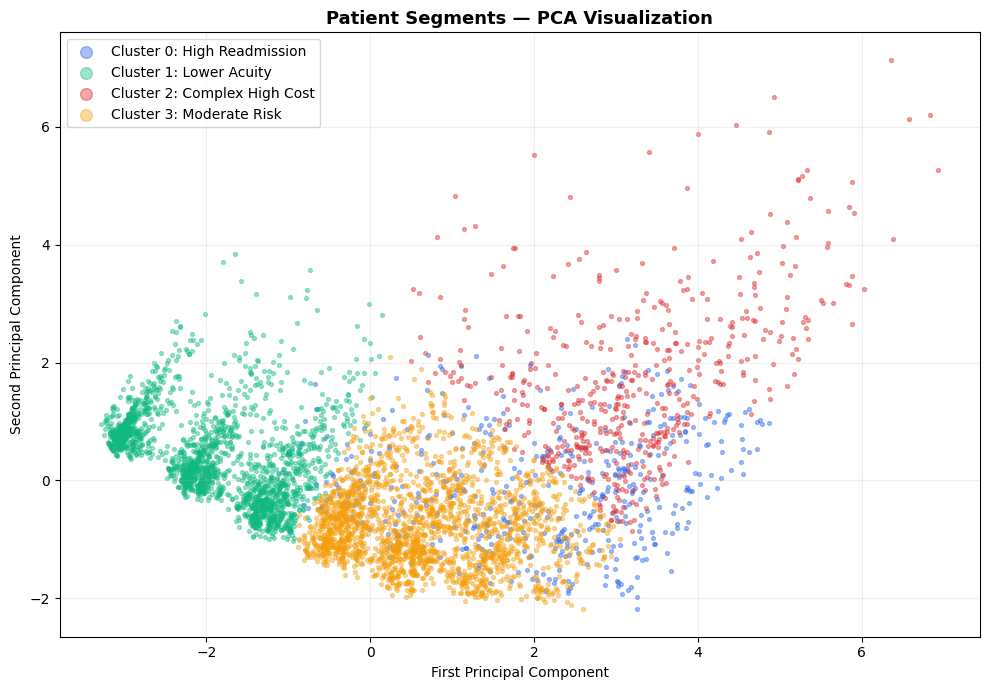

In [31]:
# Visualize clusters with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#2563EB", "#10b981", "#dc2626", "#f59e0b"]
labels = ["Cluster 0: High Readmission",
          "Cluster 1: Lower Acuity",
          "Cluster 2: Complex High Cost",
          "Cluster 3: Moderate Risk"]

sample_idx = df.sample(5000, random_state=42).index
df_sample = df.loc[sample_idx]
pca_sample = X_pca[df.index.get_indexer(sample_idx)]

for i, (color, label) in enumerate(zip(colors, labels)):
    mask = df_sample["CLUSTER"] == i
    ax.scatter(pca_sample[mask, 0], pca_sample[mask, 1],
               c=color, label=label, alpha=0.4, s=8)

ax.set_title("Patient Segments — PCA Visualization",
             fontsize=13, fontweight="bold")
ax.set_xlabel("First Principal Component")
ax.set_ylabel("Second Principal Component")
ax.legend(markerscale=3, fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../docs/charts/patient_clusters.png", dpi=150,
            bbox_inches="tight")
plt.show()

The PCA plot compresses all the patient features down to two dimensions 
so the clusters can be visualized. The green cluster separates cleanly 
on the left, which makes sense since lower acuity patients are genuinely 
different from the rest of the population. The red cluster drifts toward 
the upper right, reflecting the extreme utilization and cost that 
distinguishes those patients. The orange and blue clusters overlap in the 
middle, which is consistent with the fact that moderate risk and high 
readmission patients share many characteristics and differ mainly in 
degree rather than kind.

The overlap is not a failure of the algorithm. It reflects something true 
about the data. These are not perfectly separable groups in real life 
either, which is part of why risk stratification in healthcare is hard.

---
## 5. Key Findings and Implications

This section pulls together the main findings from the analysis and 
connects them to what they would mean in practice for a Medicare 
Advantage plan.

### What the data showed

Chronic condition count is the single strongest predictor of readmission 
risk in this dataset, climbing almost perfectly linearly from 11.5% at 
zero conditions to 94% at 11 conditions across 188,559 patients. The 
relationship is clean enough that simply counting documented conditions 
gives a health plan most of the predictive signal a sophisticated model 
would provide.

Not all conditions carry equal weight. Kidney disease and COPD are the 
strongest individual predictors of readmission once total condition count 
is controlled for, ahead of more prevalent conditions like diabetes and 
ischemic heart disease. This matters because care management programs 
tend to focus on the most common conditions rather than the ones with 
the highest independent risk signal.

Predicting readmission and predicting cost are related but different 
problems. The same features that achieve a ROC-AUC of 0.763 for 
readmission only manage 0.699 for high-cost classification, and perform 
poorly at predicting exact dollar amounts entirely. Condition flags tell 
you who will come back. They do not tell you how expensive that will be.

The clustering analysis found four patient segments that map reasonably 
well to how health plans think about member risk tiers. The most important 
finding is Cluster 2, which contains 18,371 patients with a 100% 
readmission rate and average cost over 53,000 dollars. Every patient in 
that segment was readmitted. Identifying members who match that profile 
before a hospitalization occurs would be high-value work for a case 
management team.

### What this would mean for a Medicare Advantage plan

A plan using this kind of analysis would focus case management resources 
on members with 5 or more chronic conditions, with particular attention 
to kidney disease and COPD. Members who match the Cluster 2 profile, 
high condition burden with prior utilization history, would be candidates 
for intensive outreach before their next admission rather than after it.

The finding that cost prediction requires utilization history has a 
practical implication too. New members are harder to cost-predict than 
members with claims history. Plans that invest in early engagement and 
data collection for newly enrolled members build a better foundation for 
cost management over time.

### Limitations

This analysis uses synthetic data that CMS explicitly cautions against 
using for inferential research. The patterns observed here are consistent 
with what real Medicare data tends to show, but the specific numbers 
should not be taken as representative of the actual Medicare population. 
The readmission definition used here is also simplified. Real readmission 
measures typically require a specific time window between discharge and 
return, which this analysis does not apply.